## Establishing Risk Factors for CVD using Logistic Regression: Data Cleaning
##### Lilah DuBoff

>First, let's load our packages and data in

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uci_cleveland_data = pd.read_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/01_OG_Data/UC_Irvine_Data/processed.cleveland.data",
    header=None,
)

### Information from Data Codebook and Website

14 variables used including predictor        
     

| Variable | Definition/info |
|----------|-----------------|
| age | age in years |
|sex | sex (1 = male; 0 = female) |
|cp  |  9 cp: chest pain type: Value 1: typical angina, Value 2: atypical angina, Value 3: non-anginal pain, Value 4: asymptomatic|
| trestbps | resting blood pressure (in mm Hg on admission to the hospital) |
|chol | serum cholestoral in mg/dl |
|fbs | (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false) |
| restecg | resting electrocardiographic results - Value 0: normal; Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV); Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria |
|thalach | maximum heart rate achieved |
|exang | exercise induced angina (1 = yes; 0 = no) |
|oldpeak | ST depression induced by exercise relative to rest |
|slope | the slope of the peak exercise ST segment - Value 1: upsloping; Value 2: flat; Value 3: downsloping|
|ca | number of major vessels (0-3) colored by flourosopy |
|thal | 3 = normal; 6 = fixed defect; 7 = reversable defect |
|num | the predicted attribute, diagnosis of heart disease (angiographic disease status) - Value 0: < 50% diameter narrowing; Value 1: > 50% diameter narrowing (in any major vessel: attributes 59 through 68 are vessels)|


want to add these in too, but they are not from the processed data - we will try to tackle that later

     13 smoke: I believe this is 1 = yes; 0 = no (is or is not a smoker)
     14 cigs (cigarettes per day)
     15 years (number of years as a smoker)
     17 dm (1 = history of diabetes; 0 = no such history)

In [4]:
headers = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

### Processed UCI Data from Cleveland

In [5]:
uci_cleveland_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
uci_cleveland_data.columns = headers
uci_cleveland_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [7]:
uci_cleveland_data.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

In [8]:
uci_cleveland_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

>Based on this, it would appear there are no missing values. However, upon manual inspection, there are several ? marks, which likely indicate missing data. -9 values should also be searched for

In [9]:
uci_cleveland_data_copy = uci_cleveland_data.copy()
uci_cleveland_data_copy = uci_cleveland_data_copy.astype(str)
qs_and_9s = uci_cleveland_data[
    uci_cleveland_data[
        [
            "age",
            "sex",
            "cp",
            "trestbps",
            "chol",
            "fbs",
            "restecg",
            "thalach",
            "exang",
            "oldpeak",
        ]
    ]
    .isin(["?", "-9"])
    .any(axis=1)
]

# Display the rows with '?' or '-9' values
print(qs_and_9s.head())

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, num]
Index: []


In [10]:
print(uci_cleveland_data_copy.iloc[[287, 302]])

      age  sex   cp trestbps   chol  fbs restecg thalach exang oldpeak slope  \
287  58.0  1.0  2.0    125.0  220.0  0.0     0.0   144.0   0.0     0.4   2.0   
302  38.0  1.0  3.0    138.0  175.0  0.0     0.0   173.0   0.0     0.0   1.0   

    ca thal num  
287  ?  7.0   0  
302  ?  3.0   0  


In [11]:
uci_cleveland_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


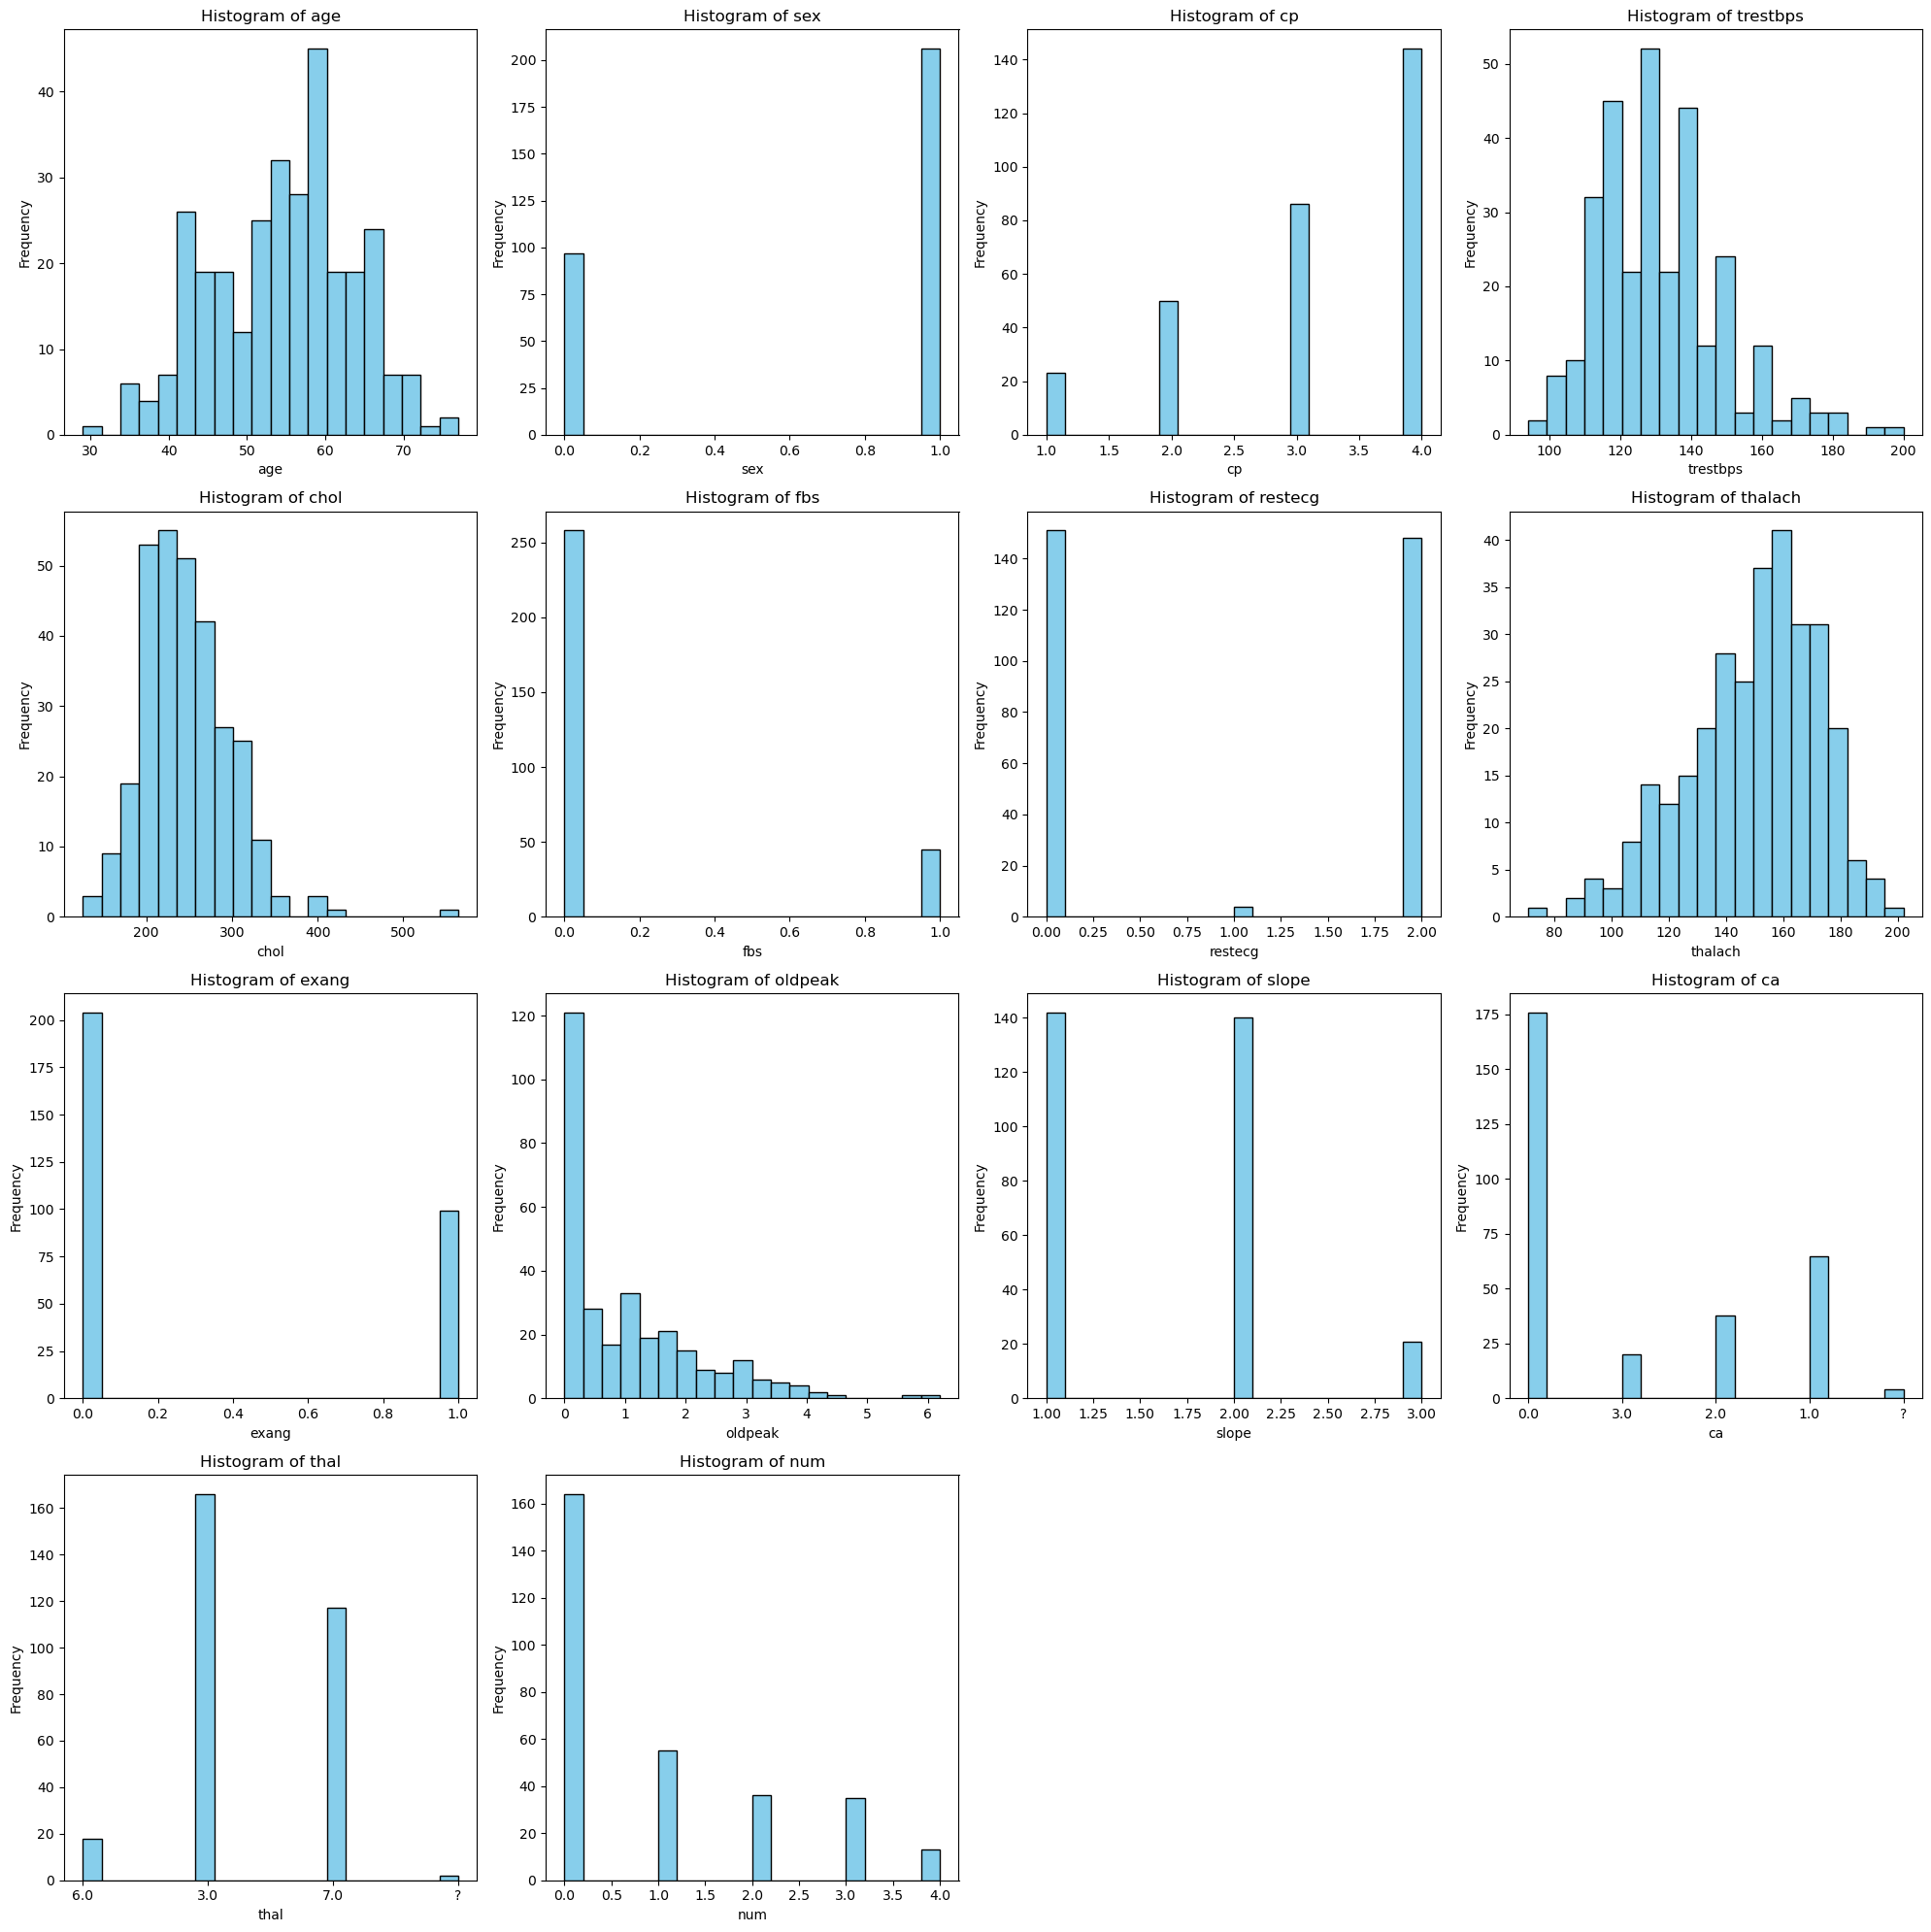

In [12]:
variables = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

plt.figure(figsize=(20, 20))

for i, var in enumerate(variables, 1):
    plt.subplot(4, 4, i)  # Creates a 4x4 grid for histograms
    plt.hist(
        uci_cleveland_data[var], bins=20, color="skyblue", edgecolor="black"
    )  # Customize bins and colors as needed
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

# Adjust layout to prevent overlapping of plots
plt.tight_layout()
plt.show()

In [13]:
uci_cleveland_data.to_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/00_Cleaned_Data/uci_cleveland_data.csv",
    index=False,
)